<a href="https://colab.research.google.com/github/VahidehRajaei/Deep-Learning-Exercises/blob/main/EuroSAT/Eurosat_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import Libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')


In [ ]:
# For repeatable results
tf.random.set_seed(42)
np.random.seed(42)

In [ ]:
DATASET_URL = "https://zenodo.org/records/7711810/files/EuroSAT_RGB.zip?download=1"

# Dataset download and extraction with Keras
dataset_path = tf.keras.utils.get_file(
    fname="EuroSAT.zip",
    origin=DATASET_URL,
    extract=True,
    archive_format="zip",
    cache_subdir="datasets"
)

search_base = dataset_path if os.path.isdir(dataset_path) else os.path.dirname(dataset_path)

# Finding the path to the folder containing the classes
data_dir = None
for root, dirs, files in os.walk(search_base):
    if any(c in dirs for c in ['Forest', 'AnnualCrop', 'River', 'SeaLake']):
        data_dir = root
        break

print("Dataset path", data_dir)
print("Number of classes", len(os.listdir(data_dir)))
print("Name of classes", sorted(os.listdir(data_dir)))


Dataset path /root/.keras/datasets/EuroSAT_extracted/EuroSAT_RGB
Number of classes 10
Name of classes ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


In [ ]:
def count_class_distribution(data_path: str) -> pd.DataFrame:

    counts = {}
    for class_name in sorted(os.listdir(data_path)):
        class_dir = os.path.join(data_path, class_name)
        if os.path.isdir(class_dir):
            counts[class_name] = len(os.listdir(class_dir))

    df = pd.DataFrame(list(counts.items()), columns=["Class", "Count"]).set_index("Class")
    return df


In [ ]:
df_counts = count_class_distribution(data_dir)
df_counts


,Count
Class,
AnnualCrop,3000
Forest,3000
HerbaceousVegetation,3000
Highway,2500
Industrial,2500
Pasture,2000
PermanentCrop,2500
Residential,3000
River,2500


In [ ]:
def plot_and_analyze_distribution(df_counts: pd.DataFrame) -> bool:

    plt.figure(figsize=(12, 6))
    sns.barplot(x=df_counts.index, y=df_counts["Count"], palette="viridis")
    plt.title("Class Distribution in EuroSAT Dataset")
    plt.xlabel("Class Name")
    plt.ylabel("Number of Images")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    is_balanced = df_counts["Count"].nunique() == 1
    if is_balanced:
        print("\n The dataset is balanced.")
    else:
        print("\n The dataset is imbalanced.")
    return is_balanced


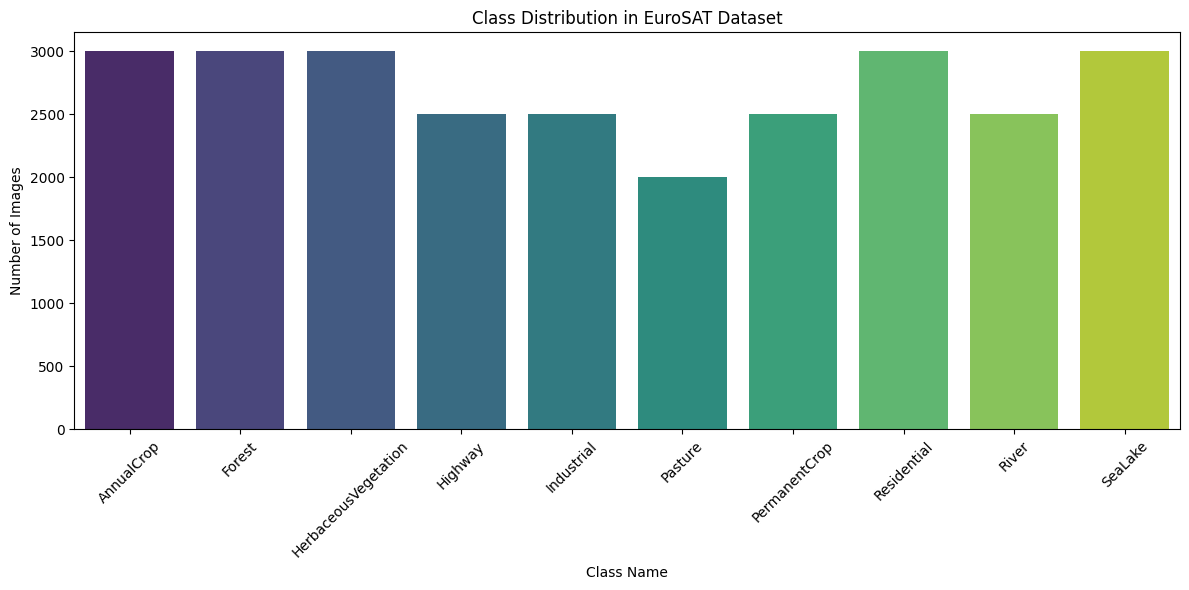


 The dataset is imbalanced.


In [ ]:
is_balanced = plot_and_analyze_distribution(df_counts)


In [ ]:
IMG_SIZE = 64         # Image size (EuroSAT satellite images have dimensions of 64x64)
BATCH_SIZE = 32        # Appropriate batch size for memory and speed optimization

In [ ]:
IMG_SIZE = 64

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)


Found 27000 files belonging to 10 classes.
Using 21600 files for training.
Found 27000 files belonging to 10 classes.
Using 5400 files for validation.


In [ ]:
class_names = train_ds.class_names
print("Class names:", class_names)
print("Number of classes:", len(class_names))


Class names: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Number of classes: 10


In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
], name="data_augmentation")


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(buffer_size=1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)


In [ ]:
def build_model(input_shape, num_classes, augmentation_layer):

    inputs = layers.Input(shape=input_shape)
    x = augmentation_layer(inputs)
    x = layers.Rescaling(1.0 / 255)(x)

    # Convolutional Block 1 (2 convolutional layers with 32 filters)
    x = layers.Conv2D(32, (3, 3), padding="same", activation="relu")(x)
    x = layers.Conv2D(32, (3, 3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(pool_size=(2, 2))(x)

    # Convolutional Block 2 (2 convolutional layers with 64 filters)
    x = layers.Conv2D(64, (3, 3), padding="same", activation="relu")(x)
    x = layers.Conv2D(64, (3, 3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(pool_size=(2, 2))(x)

    # Convolutional Block 3 (2 convolutional layers with 128 filters)
    x = layers.Conv2D(128, (3, 3), padding="same", activation="relu")(x)
    x = layers.Conv2D(128, (3, 3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(pool_size=(2, 2))(x)

    # Final Classification Layers and Preventing Overfitting
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = models.Model(inputs=inputs, outputs=outputs, name="EuroSAT_VGG_CNN")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


In [ ]:
input_shape = (IMG_SIZE, IMG_SIZE, 3)
num_classes = len(class_names)
model = build_model(input_shape, num_classes, data_augmentation)

model.summary()


Model: "EuroSAT_VGG_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 306,218 (1.17 MB)

 Trainable params: 305,514 (1.17 MB)

 Non-trainable params: 704 (2.75 KB)

In [ ]:
# Implement ModelCheckpoint
model_checkpoint = ModelCheckpoint(
    filepath="best_eurosat_model.keras",
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1
)

#  Implement EarlyStopping
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Implement ReduceLROnPlateau
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

callbacks_list = [model_checkpoint, early_stopping, reduce_lr]


In [ ]:
EPOCHS = 25

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks_list
)


Epoch 1/25
674/675 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5270 - loss: 1.3821
Epoch 1: val_accuracy improved from None to 0.35574, saving model to best_eurosat_model.keras

Epoch 1: finished saving model to best_eurosat_model.keras
675/675 ━━━━━━━━━━━━━━━━━━━━ 23s 25ms/step - accuracy: 0.6157 - loss: 1.1103 - val_accuracy: 0.3557 - val_loss: 2.5752 - learning_rate: 0.0010
Epoch 2/25
675/675 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7179 - loss: 0.7942
Epoch 2: val_accuracy improved from 0.35574 to 0.70148, saving model to best_eurosat_model.keras

Epoch 2: finished saving model to best_eurosat_model.keras
675/675 ━━━━━━━━━━━━━━━━━━━━ 15s 23ms/step - accuracy: 0.7372 - loss: 0.7502 - val_accuracy: 0.7015 - val_loss: 0.9911 - learning_rate: 0.0010
Epoch 3/25
675/675 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7758 - loss: 0.6427
Epoch 3: val_accuracy improved from 0.70148 to 0.73352, saving model to best_eurosat_model.keras

Epoch 3: finished saving model to best_euros

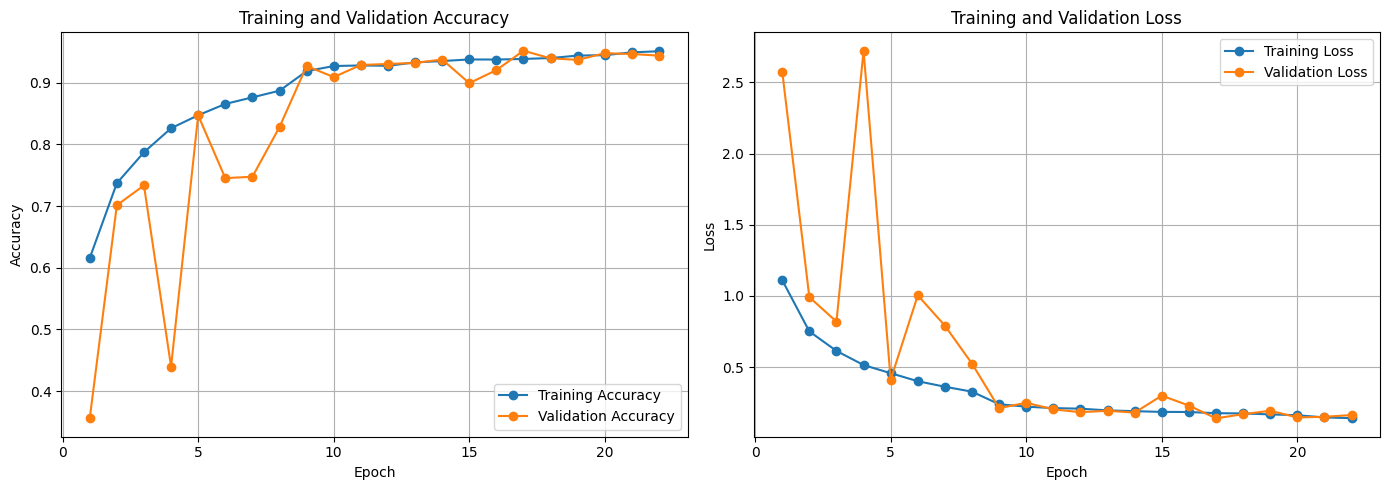

In [ ]:
# Plot Loss and Accuracy curves
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))

# Accuracy Chart
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label="Training Accuracy", marker="o")
plt.plot(epochs_range, val_acc, label="Validation Accuracy", marker="o")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(loc="lower right")
plt.grid(True)

# Loss Chart
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label="Training Loss", marker="o")
plt.plot(epochs_range, val_loss, label="Validation Loss", marker="o")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(loc="upper right")
plt.grid(True)

plt.tight_layout()
plt.show()


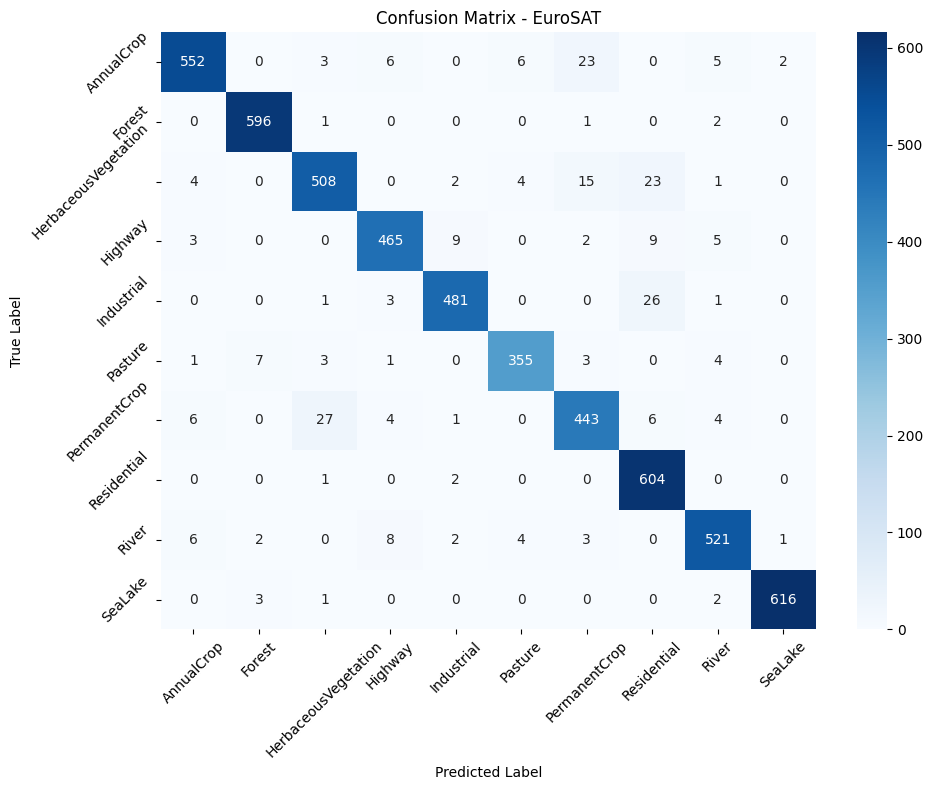

In [ ]:
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.title("Confusion Matrix - EuroSAT")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
# Classification Report
report = classification_report(y_true, y_pred, target_names=class_names)
print("Classification Report:")
print(report)


Classification Report:
                      precision    recall  f1-score   support

          AnnualCrop       0.97      0.92      0.94       597
              Forest       0.98      0.99      0.99       600
HerbaceousVegetation       0.93      0.91      0.92       557
             Highway       0.95      0.94      0.95       493
          Industrial       0.97      0.94      0.95       512
             Pasture       0.96      0.95      0.96       374
       PermanentCrop       0.90      0.90      0.90       491
         Residential       0.90      1.00      0.95       607
               River       0.96      0.95      0.95       547
             SeaLake       1.00      0.99      0.99       622

            accuracy                           0.95      5400
           macro avg       0.95      0.95      0.95      5400
        weighted avg       0.95      0.95      0.95      5400

